<a href="https://colab.research.google.com/github/jotaeleb/tif-ciencias-de-datos/blob/main/notebooks/proyecto_modelado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️TIF Análisis de Detección de Intrusiones en Red

**Grupo 1**: Gonza Gabriela · Casasola Hernán · Biazutti Luciano · Lera Aníbal Iván · Alvarado Marcelo

**Módulo**: Ciencias de Datos y Optimización de Modelos

**Carrera**: Tecnicatura Universitaria en Ciencias de Datos e IA Aplicada — UPATECO

---

# 1. Objetivos y Alcances



## 1.1 Objetivo del Análisis
Construir y evaluar modelos de Machine Learning capaces de clasificar automáticamente si un flujo de red (TCP/UDP) corresponde a tráfico legítimo (BENIGN) o a una intrusión (ataque informático).

## 1.2 Alcances del Proyecto
* **Fase de Datos:**   Se trabaja a partir de un conjunto ya preprocesado y limpio (dataset_limpio_submuestreo.parquet), libre de valores nulos o infinitos detectados en la fase previa del análisis exploratorio (EDA).

* **Variables Consideradas:** El análisis bivariado y multivariado comprende métricas temporales y volumétricas del flujo de red, tales como volumen de paquetes (Total Fwd Packets), tiempos de inter-arribo (Flow IAT Mean), tamaño de payloads (Avg Fwd Segment Size), configuraciones de puertos y banderas de control.

* **Fase de Modelado:**
    
    El alcance incluye la experimentación de tres iteraciones:
    1. Datos originales con pesos balanceados,
    2. Aplicación de SMOTE adaptativo (*k=3*)
    3. Selección de variables mediante importancia de características.

    Los resultados se comparan mediante validación cruzada estratificada y métricas robustas para datos desbalanceados.

## 1.3 Tipo de Problema
Se trata de un problema de clasificación supervisada multiclase.

El objetivo es mapear las características de un flujo de red a una de 7 etiquetas cualitativas categóricas discretas y mutuamente excluyentes, las cuales han sido codificadas mediante un LabelEncoder de la siguiente manera:

* 0 $\rightarrow$ BENIGN (Tráfico normal legítimo)
* 1 $\rightarrow$ Botnet (Redes de computadoras infectadas bajo control remoto)
* 2 $\rightarrow$ Brute Force (Ataques de fuerza bruta para adivinación de credenciales)
* 3 $\rightarrow$ DoS-DDoS (Ataques de denegación de servicio distribuidos o simples)
* 4 $\rightarrow$ PortScan (Escaneo y reconocimiento de puertos abiertos de la red)
* 5 $\rightarrow$ Rare Attack (Ataques de infiltración altamente inusuales y escasos)
* 6 $\rightarrow$ Web Attack (Ataques dirigidos a aplicaciones web, por ejemplo HTTP vulnerables)

## 1.4 Flujo Metodológico a seguir
Dado que es un problema de clasificación multiclase con desbalance severo, el proyecto ejecuta las siguientes actividades especializadas para este tipo de modelos:

1. **Estrategia de Partición:** División del conjunto en un 80% para Entrenamiento (134,403 filas) y un 20% para Prueba (33,601 filas), implementando una partición estratificada (stratify=y) para garantizar que la pequeña proporción de ataques raros se mantenga idéntica en ambos sets.

2. **Validación Cruzada Estratificada:** Uso de StratifiedKFold con 5 pliegues (splits). Esto evita el riesgo de que algún bloque de evaluación quede vacío de ataques minoritarios.

3. **Métricas de Evaluación Específicas para Clasificación:**
    * Recall Macro / Balanced Accuracy: Promedio del porcentaje de aciertos de cada clase de forma individual. Es vital porque otorga el mismo peso al ataque más raro que al tráfico benigno.
    * Precision Macro: Evalúa la proporción de alertas que son ciberataques reales, penalizando las falsas alarmas de forma equitativa.
    * F1 Macro: La media armónica entre precisión y recall para diagnosticar el balance global del clasificador.

4. **Análisis de Confusión:** Generación de matrices de confusión normalizadas por fila para inspeccionar visualmente qué tipos de ataques tiende a confundir el modelo entre sí (por ejemplo, la similitud estructural en la red entre Brute Force y Web Attack).

# 2. Análisis exploratorio de datos

## 2.1 Librerías

In [ ]:
# Instalar imbalanced-learn si no está disponible
!pip install imbalanced-learn -q

In [ ]:
# Librerías generales
import io, requests, warnings
import time
from datetime import datetime
import numpy as np
import pandas as pd
from pandas.api.types import is_string_dtype
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import display, HTML
from scipy.stats import randint, uniform

# Estructura y Preprocesamiento
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.utils.class_weight import compute_sample_weight

# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluación
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)

warnings.filterwarnings('ignore')

# Paleta de colores
PALETA = {
    'BENIGN':'#2E7D32', # Verde oscuro
    'DoS/DDoS':'#C62828', # Rojo fuerte
    'PortScan':'#1565C0',  # Azul corporativo
    'Brute Force':'#EF6C00', # Naranja intenso
    'Web Attack':'#D84315', # Rojo anaranjado
    'Botnet':'#6A1B9A', # Violeta profundo
    'Rare Attack':'#00838F', # Cian oscuro
}

## 2.2 Carga Dataset limpio con submuestreo



Con 2,8 millones de filas, entrenar modelos en Colab puede consumir demasiada memoria y tiempo. Por eso vamos a utilizar una muestra de 168004 filas, que permite obtener resultados representativos con menor costo computacional.

El archivo dataset_limpio_submuestreo.parquet se carga directamente desde GitHub y ya se encuentra limpia, sin valores nulos ni columnas problemáticas, según el análisis realizado en proyecto_eda.ipynb.

In [ ]:
#Esta función carga un dataset desde el repo de Github
def cargarDataset(archivos):

  GITHUB_USER = 'jotaeleb'
  GITHUB_REPO = 'tif-ciencias-de-datos'
  GITHUB_BRANCH = 'main'
  DATASET_DIR = 'dataset'

  BASE_URL = (
    f'https://raw.githubusercontent.com/'
    f'{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{DATASET_DIR}'
  )

  partes = []
  for archivo in archivos:
    url = f'{BASE_URL}/{archivo}'
    print(f"Cargando archivo {url}")
    partes.append(pd.read_parquet(io.BytesIO(requests.get(url).content)))


  completo = pd.concat(partes,ignore_index=True)
  completo['Label'] = completo['Label'].str.replace(r'[^\w\s-]', '-', regex=True)

  return completo

#Esta función devuelve las columnas numéricas del dataset
def colNumericas(dFrame):
  columnas = []
  for columna, tipoDato in dFrame.dtypes.items():
    if not is_string_dtype(tipoDato):
      columnas.append(columna)
  return columnas

#Esta función evalúa el modelo
def evaluarModelo(y_prueba, predicciones,clases=None):
  accuracy = accuracy_score(y_prueba, predicciones)
  f1Macro = f1_score(y_prueba, predicciones, average='macro')
  print(f"Accuracy: {accuracy:.3f} | F1 Macro: {f1Macro:.3f}")

  if (clases is not None):
    reporte = classification_report(y_prueba,predicciones,target_names=clases,output_dict=True)
  else:
    reporte = classification_report(y_prueba,predicciones,output_dict=True)

  dfReporte = pd.DataFrame(reporte).transpose()
  dfReporte = dfReporte.round(4)
  display(HTML(dfReporte.to_html()))

  #Esta función lista categorias codificadas
  def verCategorias():
    pass

In [ ]:
print("Carga Dataset")
df = cargarDataset(["dataset_limpio_submuestreo.parquet"])
print(df.shape)

Carga Dataset
Cargando archivo https://raw.githubusercontent.com/jotaeleb/tif-ciencias-de-datos/main/dataset/dataset_limpio_submuestreo.parquet
(168004, 66)


In [ ]:
# Categorías
df['Label'].value_counts()

,count
Label,
BENIGN,50000
PortScan,50000
DoS-DDoS,50000
Brute Force,13826
Web Attack,2159
Botnet,1956
Rare Attack,63


Este desbalance extremo (ratio 500:1 entre la mayoría y Rare Attack) es el principal desafío técnico del proyecto.

## 2.3 Síntesis del Análisis Exploratorio

### Análisis univariado de las variables predictoras

El dataset CICIDS2017 contiene **66 features numéricas** que caracterizan flujos de red (TCP/UDP) desde distintas perspectivas estadísticas: volumen de paquetes, tiempos inter-arribo (IAT), longitudes de payload, flags de control y tasas de transferencia.

Las distribuciones de estas variables presentan tres patrones recurrentes:

- **Alta asimetría positiva (skewness):** La mayoría de features de conteo y longitud (ej. `Total Fwd Packets`, `Packet Length Max`) tienen distribuciones con cola larga a la derecha. La gran masa de tráfico benigno genera valores moderados, mientras que ciertos ataques producen valores extremos. Esto justificó el uso de `RobustScaler` en las etapas de preprocesamiento.

- **Presencia de outliers extremos:** Variables como `Flow IAT Max` e `Init_Win_bytes_forward` registran valores hasta cientos de desviaciones estándar por encima de la mediana. Estos outliers no son errores: son la firma estadística de ciertos ataques (DoS, Port Scan). Eliminarlos sería una pérdida de información crítica.

- **Alta correlación entre features relacionadas:** `Fwd Packet Length Mean` y `Fwd Packet Length Max` comparten información redundante. Esta correlación motivó la selección de variables en la Sección 7.

### Análisis bivariado: variable objetivo vs. predictoras

La relación entre `Label` y las features revela separabilidad diferencial por clase:

| Clase | Feature más discriminativa | Patrón observado |
|---|---|---|
| **DoS/DDoS** | `Flow Bytes/s`, `Flow Packets/s` | Tasas de transferencia extremadamente altas |
| **PortScan** | `Destination Port`, `Flow Duration` | Conexiones cortas a múltiples puertos |
| **Brute Force** | `Fwd Packets/s`, `Init_Win_bytes_forward` | Muchos paquetes pequeños y rápidos |
| **Web Attack** | `Destination Port` (80/443), `Avg Fwd Segment Size` | Tráfico HTTP/HTTPS con payloads variables |
| **Botnet** | `Flow IAT Mean`, `Packet Length Mean` | Tráfico periódico de baja intensidad |
| **Rare Attack** | Múltiples features con valores límite | Sin patrón dominante único → difícil detección |

### Desbalance de clases: el desafío central

```
Label
BENIGN         ~73%   ████████████████████████████
DoS/DDoS       ~18%   ███████
PortScan        ~5%   ██
Brute Force     ~2%   █
Web Attack      ~1%   ▌
Botnet         ~0.5%  ▎
Rare Attack    ~0.1%  ·
```

Un modelo que prediga siempre BENIGN obtendría ~73% de accuracy. Por eso el accuracy global **no es una métrica adecuada** para este problema. Se prioriza **Recall Macro** (detectar cada tipo de ataque) sobre accuracy.

### Transformaciones aplicadas

- **Eliminación de NaN:** El dataset limpio (`dataset_limpio_submuestreo.parquet`) ya fue procesado en la Entrega 1: columnas con NaN sistemáticos (`Flow Bytes/s`, `Flow Packets/s`) fueron imputadas o descartadas según el caso.
- **Codificación del target:** `LabelEncoder` transforma las 7 clases a enteros 0–6, requisito de la API de scikit-learn y XGBoost.
- **No se aplica escalado global:** Los modelos basados en árboles (DT, RF, XGBoost) son invariantes a la escala; no requieren normalización. Esto simplifica el pipeline y evita data leakage en la validación cruzada.


# 3. Modelado

## 3.1 Preparación de los Datos

Antes de entrenar cualquier modelo necesitamos hacer dos cosas:
1. **Separar** la variable objetivo `Label` del resto de variables (features).
2. **Codificar** el `Label` como número, porque los modelos trabajan con números, no con texto.

### 3.1.1 Separar features y target

In [ ]:
# Variable objetivo
y_texto = df['Label']

# Features: todas las columnas numéricas excepto Label
X = df.drop(columns=['Label'])

# Conservamos solo columnas numéricas
X = X.select_dtypes(include=np.number)

print(f'Features (X): {X.shape[1]} columnas')
print(f'Target (y): {y_texto.nunique()} clases')

Features (X): 65 columnas
Target (y): 7 clases


### 3.1.2 Codificar el target

In [ ]:
# LabelEncoder convierte cada clase en un número entero.
le = LabelEncoder()
y = le.fit_transform(y_texto)

# Mostramos el mapeo para no perder la referencia
mapeo = dict(zip(le.classes_, le.transform(le.classes_)))
print('Mapeo de clases:')
for clase, numero in sorted(mapeo.items(), key=lambda x: x[1]):
    print(f'  {numero} → {clase}')

Mapeo de clases:
  0 → BENIGN
  1 → Botnet
  2 → Brute Force
  3 → DoS-DDoS
  4 → PortScan
  5 → Rare Attack
  6 → Web Attack


## 3.2 División Train / Test

Dividimos el dataset en:
- **80% entrenamiento**: los datos con los que el modelo aprende.
- **20% prueba**: los datos que el modelo nunca vio, para evaluar qué tan bien generaliza.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # mantiene la proporción de clases
)

print(f'Entrenamiento: {X_train.shape[0]:,} filas')
print(f'Prueba: {X_test.shape[0]:,} filas')

# Verificamos que la proporción se respetó
print('\nProporción de clases en train:')
clases_train = pd.Series(y_train).map(dict(zip(le.transform(le.classes_), le.classes_)))
print(clases_train.value_counts(normalize=True).round(3))

Entrenamiento: 134,403 filas
Prueba: 33,601 filas

Proporción de clases en train:
PortScan       0.298
BENIGN         0.298
DoS-DDoS       0.298
Brute Force    0.082
Web Attack     0.013
Botnet         0.012
Rare Attack    0.000
Name: proportion, dtype: float64


## 3.3 Configuración de Validación Cruzada

**¿Por qué usamos Validación Cruzada?**

Evaluar el modelo con una única partición de entrenamiento y prueba puede generar resultados sesgados, ya que estos dependen de cómo se realizó la división de los datos. Para obtener una evaluación más confiable, se utilizó validación cruzada, que entrena y evalúa el modelo varias veces con distintas particiones y reporta el promedio de los resultados.

In [ ]:
# Configurar Stratified K-Fold
# n_splits=5: dividir los datos en 5 partes
# shuffle=True: mezclar antes de dividir
# random_state=42: fija la semilla para reproducibilidad

CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
# Definir las métricas a reportar
SCORING = {
    "recall_macro": make_scorer(recall_score, average="macro"),
    "precision_macro": make_scorer(precision_score, average="macro"),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "balanced_accuracy": make_scorer(balanced_accuracy_score)
}

# Función auxiliar para mostrar resultados
def mostrar_cv_resultados(cv_results, nombre_modelo):
    """
    Toma los resultados de cross_validate() y muestra un resumen claro.
    Cada métrica muestra: promedio ± desviación estándar.
    La desviación estándar nos dice qué tan estables son los resultados:
    - ± bajo → el modelo es consistente entre pliegues (buena señal)
    - ± alto → el modelo es inestable (posible overfitting o datos ruidosos)
    """
    print(f" {nombre_modelo}")

    metricas_mostrar = {
        'test_recall_macro': 'Recall Macro',
        'test_precision_macro': 'Precision Macro',
        'test_f1_macro': 'F1 Macro',
        'test_balanced_accuracy': 'Balanced Accuracy',
    }

    for key, nombre in metricas_mostrar.items():
        vals = cv_results[key]
        print(f"  {nombre}: {vals.mean():.4f}  (± {vals.std():.4f})")

    print(f"Tiempo promedio/fold: {cv_results['fit_time'].mean():.1f}s")

# Función auxiliar para graficar la matriz de confusión
def graficar_confusion(y_true, y_pred, titulo, le):
    """
    Grafica la matriz de confusión normalizada por fila (recall por clase).
    Cada celda (i, j) muestra: de todos los ejemplos de la clase i,
    qué proporción el modelo clasificó como clase j.
    La diagonal principal (en azul oscuro) es lo que queremos maximizar.
    """
    cm = confusion_matrix(y_true, y_pred, normalize='true')  # normalizada por fila
    fig, ax = plt.subplots(figsize=(9, 7))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')

    ax.set_title(titulo, fontsize=11, pad=12)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# Confirmación de configuración
print("Estrategia de validación cruzada configurada.")
print(" Estrategia: StratifiedKFold")
print(" Pliegues: 5")
print(" Métricas: Recall Macro, Precision Macro, F1 Macro, Balanced Accuracy")

Estrategia de validación cruzada configurada.
 Estrategia: StratifiedKFold
 Pliegues: 5
 Métricas: Recall Macro, Precision Macro, F1 Macro, Balanced Accuracy



**¿Por qué Stratified K-Fold?**

Con el desbalance extremo de este dataset, un K-Fold simple podría crear un fold donde la clase Rare Attack no tenga ningún ejemplo en el conjunto de evaluación. **StratifiedKFold** garantiza que cada fold tenga la misma proporción de todas las clases que el dataset completo.

**Métricas elegidas**

| Métrica | Fórmula | Por qué se usa aquí |
|---|---|---|
| **Recall Macro** | Promedio no ponderado del recall por clase | Penaliza igualmente fallar en Rare Attack que en BENIGN |
| **Precision Macro** | Promedio no ponderado de la precisión por clase | Evalúa las falsas alarmas de forma equitativa entre clases |
| **F1 Macro** | Media armónica de Precision y Recall Macro | Balance entre detección y falsas alarmas |
| **Balanced Accuracy** | Promedio de recall por clase | Equivale al Recall Macro; confirma consistencia |

**¿Por qué `macro` y no `weighted`?**

La versión `weighted` pondera cada clase por su frecuencia. Con el desbalance de este dataset, ponderar por frecuencia haría que las métricas de BENIGN (clase mayoritaria) dominen completamente el promedio, ocultando el desempeño real en los ataques minoritarios. La versión `macro` le asigna el mismo peso a Rare Attack que a BENIGN, que es exactamente lo que se quiere en un sistema de detección de intrusiones donde cada tipo de ataque importa.

## 3.4 Primera Iteración

En esta primera Iteración entrenamos los modelos usando el dataset tal como está, sin generar muestras sintéticas. Para compensar el desbalance extremo, usamos el parámetro `class_weight='balanced'`.

**¿Qué hace `class_weight='balanced'`?**

Debido al desbalance de clases del dataset, se utilizó class_weight='balanced', que asigna mayor importancia a las clases con menos ejemplos. De esta forma, los errores cometidos sobre clases minoritarias reciben una penalización más alta durante el entrenamiento, ayudando al modelo a mejorar su capacidad de detección en estas categorías.

### 3.4.1 Árbol de Decisión Baseline

In [ ]:
# max_depth=15: evita que el árbol crezca infinitamente (overfitting)
# class_weight='balanced': ajusta el peso de cada clase automáticamente

dt_base = DecisionTreeClassifier(
    max_depth=15,
    class_weight="balanced",
    random_state=42
)

# Validación cruzada
cv_dt_base = cross_validate(
    dt_base, X_train, y_train,
    cv=CV,
    scoring=SCORING,
    n_jobs=-1  # Utiliza todos los núcleos disponibles del procesador
)

mostrar_cv_resultados(cv_dt_base, "Árbol de Decisión — Baseline (sin SMOTE)")

 Árbol de Decisión — Baseline (sin SMOTE)
  Recall Macro: 0.9557  (± 0.0272)
  Precision Macro: 0.9162  (± 0.0277)
  F1 Macro: 0.9314  (± 0.0245)
  Balanced Accuracy: 0.9557  (± 0.0272)
Tiempo promedio/fold: 6.7s


El árbol de decisión demostró un gran desempeño y estabilidad en la validación cruzada. Con un Recall Macro del 95,57% y una Balanced Accuracy idéntica, el modelo es altamente efectivo para identificar todas las clases, priorizando la detección de ataques sobre la reducción de falsas alarmas (lo que explica una Precisión Macro ligeramente menor, del 91,62%). El F1 Macro (93,14%) ratifica este buen equilibrio. Además, la baja desviación estándar (± 0,0272) asegura que los resultados son consistentes en los diferentes folds, mientras que el tiempo de entrenamiento (6,6 segundos por fold) lo consolida como una solución rápida y computacionalmente eficiente.

### 3.4.2 Random Forest Baseline

Random Forest es un modelo que combina múltiples árboles de decisión entrenados en paralelo con muestras y variables aleatorias, definiendo el resultado por votación mayoritaria. Sus mayores ventajas son que evita el overfitting (el promedio de los árboles cancela los errores individuales) y es sumamente robusto frente a outliers y datos irrelevantes.

In [ ]:
# n_estimators=100: cantidad de árboles
# class_weight='balanced_subsample': similar a balanced, pero recalcula los pesos en cada bootstrap sample
# n_jobs=-1: paraleliza el entrenamiento usando todos los núcleos

rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

cv_rf_base = cross_validate(
    rf_base, X_train, y_train,
    cv=CV,
    scoring=SCORING,
    n_jobs=-1
)

mostrar_cv_resultados(cv_rf_base, "Random Forest — Baseline (sin SMOTE)")

 Random Forest — Baseline (sin SMOTE)
  Recall Macro: 0.9327  (± 0.0195)
  Precision Macro: 0.9894  (± 0.0026)
  F1 Macro: 0.9508  (± 0.0161)
  Balanced Accuracy: 0.9327  (± 0.0195)
Tiempo promedio/fold: 67.9s


Random Forest superó notablemente al Árbol de Decisión en precisión general, alcanzando un 98,94% de Precisión Macro (lo que reduce drásticamente las falsas alarmas). Aunque es un poco más conservador en la detección —su Recall Macro bajó al 93,27% frente al 95,57% del Árbol—, el balance global es superior, logrando el F1 Macro más alto hasta ahora (95,08%). Además, demostró ser un modelo más estable y robusto entre folds (desviación estándar de ±0,0195). La única desventaja real es su costo computacional: el tiempo de entrenamiento se multiplicó por diez, subiendo a 68,1 segundos por fold.

### 3.4.3 XGBoost Baseline

XGBoost (*eXtreme Gradient Boosting*) es un algoritmo de boosting que construye árboles de decisión de forma secuencial: cada árbol nuevo aprende a corregir los errores del árbol anterior. A diferencia de Random Forest (donde los árboles se construyen en paralelo de forma independiente), en XGBoost cada árbol depende del anterior, lo que lo hace más preciso pero también más sensible a los hiperparámetros.

In [ ]:
# Definimos el modelo XGBoost para clasificación multiclase
xgb_base = XGBClassifier(
    objective='multi:softprob',   # probabilidades por clase
    eval_metric='mlogloss',        # log-loss multiclase como métrica interna
    num_class=len(le.classes_),    # cantidad de clases
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# cross_validate no pasa sample_weight automáticamente a fit(), así que
# hacemos manualmente la validación cruzada con StratifiedKFold (CV).

metricas_xgb = {'recall_macro': [], 'precision_macro': [], 'f1_macro': [], 'balanced_accuracy': [], 'fit_time': []}

X_train_arr = np.asarray(X_train)
y_train_arr = np.asarray(y_train)

for fold_idx, (idx_tr, idx_val) in enumerate(CV.split(X_train_arr, y_train_arr), start=1):
    modelo_fold = clone(xgb_base)

    X_tr, X_val = X_train_arr[idx_tr], X_train_arr[idx_val]
    y_tr, y_val = y_train_arr[idx_tr], y_train_arr[idx_val]

    # Pesos calculados SOLO con los datos de entrenamiento de este fold
    pesos_fold = compute_sample_weight(class_weight='balanced', y=y_tr)

    inicio = time.time()
    modelo_fold.fit(X_tr, y_tr, sample_weight=pesos_fold)
    metricas_xgb['fit_time'].append(time.time() - inicio)

    pred_val = modelo_fold.predict(X_val)

    metricas_xgb['recall_macro'].append(recall_score(y_val, pred_val, average='macro'))
    metricas_xgb['precision_macro'].append(precision_score(y_val, pred_val, average='macro'))
    metricas_xgb['f1_macro'].append(f1_score(y_val, pred_val, average='macro'))
    metricas_xgb['balanced_accuracy'].append(balanced_accuracy_score(y_val, pred_val))

cv_xgb_base = {
    'test_recall_macro': np.array(metricas_xgb['recall_macro']),
    'test_precision_macro': np.array(metricas_xgb['precision_macro']),
    'test_f1_macro': np.array(metricas_xgb['f1_macro']),
    'test_balanced_accuracy': np.array(metricas_xgb['balanced_accuracy']),
    'fit_time': np.array(metricas_xgb['fit_time']),
}

mostrar_cv_resultados(cv_xgb_base, "XGBoost — Baseline (sin SMOTE)")

# Pesos calculados sobre TODO X_train, para usarlos luego al entrenar el modelo final
pesos_train = compute_sample_weight(class_weight='balanced', y=y_train)


 XGBoost — Baseline (sin SMOTE)
  Recall Macro: 0.9752  (± 0.0198)
  Precision Macro: 0.9886  (± 0.0100)
  F1 Macro: 0.9798  (± 0.0098)
  Balanced Accuracy: 0.9752  (± 0.0198)
Tiempo promedio/fold: 57.5s


XGBoost Baseline presentó un desempeño excelente, alcanzando un Recall Macro de 97.52%, Precision Macro de 98.86%, F1 Macro de 97.98% y Balanced Accuracy de 97.52%. Las bajas desviaciones estándar indican que el modelo es estable y consistente entre los distintos folds de validación. Además, logró estos resultados sin aplicar técnicas de balanceo, con un tiempo promedio de 57.5 segundos por fold.

### 3.4.4 Evaluación sobre el Test Set — Mejor Modelo

Mejor modelo de la 1era Interacción: XGBoost

REPORTE — XGBoost (Test Set)


,precision,recall,f1-score,support
BENIGN,0.999,0.998,0.999,10000.000
Botnet,0.977,0.992,0.985,391.000
Brute Force,1.000,1.000,1.000,2765.000
DoS-DDoS,1.000,1.000,1.000,10000.000
PortScan,1.000,1.000,1.000,10000.000
Rare Attack,0.667,0.769,0.714,13.000
Web Attack,0.993,0.991,0.992,432.000
accuracy,0.999,0.999,0.999,0.999
macro avg,0.948,0.964,0.956,33601.000
weighted avg,0.999,0.999,0.999,33601.000


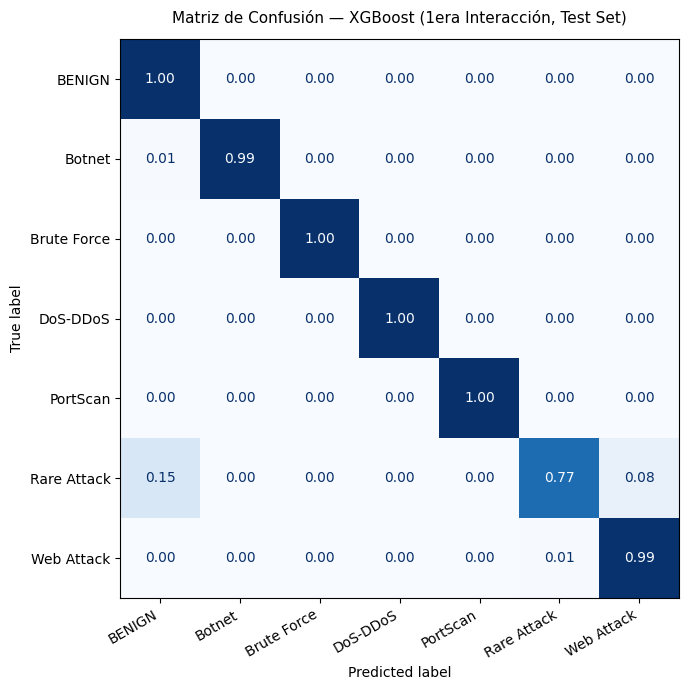

In [ ]:
# Seleccionar mejor modelo según F1 Macro en CV
# Creamos un diccionario vinculando los resultados de CV y los objetos de los modelos
resultados_exp1 = {
    'Árbol de Decisión': (cv_dt_base, dt_base),
    'Random Forest': (cv_rf_base, rf_base),
    'XGBoost': (cv_xgb_base, xgb_base),
}

# Buscamos automáticamente el modelo con el promedio de F1 Macro más alto en CV
mejor_nombre_exp1 = max(
    resultados_exp1.keys(),
    key=lambda k: resultados_exp1[k][0]['test_f1_macro'].mean()
)
_, mejor_modelo_exp1 = resultados_exp1[mejor_nombre_exp1]

print(f"Mejor modelo de la 1era Iteración: {mejor_nombre_exp1}")

# Entrenamos el mejor modelo con TODO X_train (unión de todos los folds)
# Nota: si el ganador es XGBoost, necesita los sample_weight calculados en 5.4
if mejor_nombre_exp1 == 'XGBoost':
    mejor_modelo_exp1.fit(X_train, y_train, sample_weight=pesos_train)
else:
    mejor_modelo_exp1.fit(X_train, y_train)

# Generamos las predicciones definitivas sobre el conjunto de Test
y_pred_exp1 = mejor_modelo_exp1.predict(X_test)

# Reporte completo de clasificación
reporte_dict = classification_report(
    y_test, y_pred_exp1,
    target_names=le.classes_,
    zero_division=0,
    output_dict=True # Fix: ensure classification_report returns a dictionary
)
df_reporte = pd.DataFrame(reporte_dict).transpose()
print(f"\nREPORTE — {mejor_nombre_exp1} (Test Set)")
display(df_reporte.round(3))

# Matriz de confusión
graficar_confusion(
    y_test,
    y_pred_exp1,
    f'Matriz de Confusión — {mejor_nombre_exp1} (1era Iteración, Test Set)',
    le
)


**Análisis de la Matriz de Confusión (XGBoost, Test Set):**

La matriz de confusión normalizada por fila muestra el **Recall por clase**: qué proporción de los ejemplos reales de cada clase el modelo clasificó correctamente.

Patrones esperados y su interpretación:

- **Diagonal alta en BENIGN y DoS/DDoS**: estas clases tienen miles de ejemplos de entrenamiento, el modelo las aprende sólidamente.
- **Diagonal alta en PortScan**: los ataques de escaneo tienen patrones de tráfico muy distintivos (muchas conexiones en ráfaga a múltiples puertos), fáciles de separar.
- **Confusión entre Brute Force y Web Attack**: ambos involucran intentos repetidos de autenticación HTTP, con features de red similares (mismos puertos destino, patrones de payload parecidos).
- **Confusión entre Botnet y Rare Attack**: ambas clases son muy pequeñas; el modelo puede confundir patrones de tráfico de botnet de baja intensidad con ataques raros de infiltración.
- **Celda (i, i) baja para Rare Attack**: la clase con menos muestras es la más difícil. Incluso con `sample_weight`, la señal de gradiente de estas pocas muestras puede ser insuficiente para separar bien esta clase.

## 3.5 Segunda Iteración - Aplicación de SMOTE

SMOTE es una técnica de sobremuestreo que equilibra los datasets generando datos sintéticos de la clase minoritaria, en lugar de simplemente duplicar filas (lo que causaría overfitting). Para crear estas nuevas muestras artificiales, utiliza el algoritmo k-NN para realizar una interpolación geométrica entre los datos reales más cercanos.

**Estrategia de Muestreo**

* k_neighbors=3 (Robustez): Se reduce el valor por defecto ($k=5$) a $k=3$ porque la clase 'Rare Attack' cuenta con muy pocas muestras. Esto reduce el requisito mínimo a 4 muestras por clase en el subset de entrenamiento, evitando que el código falle con un ValueError durante la validación cruzada.
* sampling_strategy Personalizada (Balance vs. Overfitting): En lugar de igualar todas las clases de forma masiva (lo que inflaría el dataset artificialmente), se definen topes controlados (e.g., 4,000 para Rare Attack y 12,000 para Botnet). Esto le da al modelo el volumen necesario para aprender a detectar los ataques minoritarios sin caer en un sobreajuste (overfitting) severo por exceso de datos sintéticos.

In [ ]:
# Configurar SMOTE
# Definimos una estrategia de muestreo personalizada
estrategia_muestreo = {
    'Brute Force': 20000,
    'Web Attack': 12000,
    'Botnet': 12000,
    'Rare Attack': 4000
}

# 'mapeo' fue calculado en la sección 2.2: Lo usamos para traducir los nombres
# de clase a los códigos numéricos que usan y_train / y_balanceado
estrategia_muestreo_codificada = {
    mapeo[clase]: cantidad
    for clase, cantidad in estrategia_muestreo.items()
}

print("Estrategia de muestreo (códigos numéricos):")
for codigo, cantidad in estrategia_muestreo_codificada.items():
    print(f"  {le.inverse_transform([codigo])[0]} ({codigo}): {cantidad}")

Estrategia de muestreo (códigos numéricos):
  Brute Force (2): 20000
  Web Attack (6): 12000
  Botnet (1): 12000
  Rare Attack (5): 4000


### 3.5.1 SMOTE + Árbol de Decisión

In [ ]:
# Usamos ImbPipeline para asegurar que SMOTE se aplique exclusivamente
# en el Train de cada fold, protegiendo el bloque de validación.
dt_smote = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=estrategia_muestreo_codificada, k_neighbors=3, random_state=42)),
    ('modelo', DecisionTreeClassifier(
        max_depth=15,
        class_weight='balanced',
        random_state=42
    ))
])

# Ejecución de la validación cruzada en paralelo
cv_dt_smote = cross_validate(
    dt_smote, X_train, y_train,
    cv=CV,
    scoring=SCORING,
    return_train_score=False,
    n_jobs=-1  # Distribuye los folds eficientemente entre todos los núcleos
)

mostrar_cv_resultados(cv_dt_smote, "Árbol de Decisión con SMOTE")

 Árbol de Decisión con SMOTE
  Recall Macro: 0.9560  (± 0.0187)
  Precision Macro: 0.8743  (± 0.0324)
  F1 Macro: 0.8937  (± 0.0340)
  Balanced Accuracy: 0.9560  (± 0.0187)
Tiempo promedio/fold: 19.4s


Al añadir SMOTE al árbol, el efecto más probable es una mejora en el Recall de las clases minoritarias a costa de posible reducción de Precision. El árbol ya tiene `class_weight='balanced'`, que ajusta los pesos internamente. Al combinar ambas técnicas (pesos + datos sintéticos), el modelo recibe una señal doble: datos adicionales de las clases minoritarias Y mayor penalización por errar en ellas.

Esto puede generar **sobredetección**: el modelo declara ataque ante cualquier ambigüedad, aumentando las falsas alarmas. El impacto en F1 Macro depende de cuál efecto domina.

### 3.5.2 SMOTE + Random Forest

In [ ]:
# max_depth=20: Controla el crecimiento de los árboles para evitar sobreajuste
# n_estimators=100: Número de árboles en el bosque
# class_weight='balanced_subsample': Calcula los pesos basados en el bootstrap de cada árbol
rf_smote = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=estrategia_muestreo_codificada, k_neighbors=3, random_state=42)),
    ('modelo', RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1  # Paraleliza el entrenamiento de los árboles internamente
    ))
])

# Ejecución de la validación cruzada
cv_rf_smote = cross_validate(
    rf_smote, X_train, y_train,
    cv=CV,
    scoring=SCORING,
    return_train_score=False,
    n_jobs=-1  # Distribuye los folds en paralelo
)

mostrar_cv_resultados(cv_rf_smote, "Random Forest con SMOTE")

 Random Forest con SMOTE
  Recall Macro: 0.9504  (± 0.0171)
  Precision Macro: 0.9701  (± 0.0122)
  F1 Macro: 0.9568  (± 0.0128)
  Balanced Accuracy: 0.9504  (± 0.0171)
Tiempo promedio/fold: 80.1s


Random Forest es el modelo que más se beneficia de SMOTE entre los tres:

- El mecanismo de bootstrap sampling de RF ya genera variedad en los datos de entrenamiento de cada árbol. Al añadir muestras sintéticas de clases minoritarias, algunos árboles del ensemble que antes no tenían ningún ejemplo de Botnet o Rare Attack en su bootstrap sample ahora sí los tienen.
- La robustez natural de RF a datos ruidosos ayuda a "absorber" las muestras sintéticas de SMOTE sin sobreajustarse a ellas.

### 3.5.3 SMOTE + XGBoost



In [ ]:
# XGBoost no se integra de forma directa con cross_validate
# Por eso armamos manualmente el bucle de validación cruzada:
#  1. En cada fold, aplicamos SMOTE SOLO sobre el fold de entrenamiento.
#  2. Entrenamos XGBoost sobre los datos balanceados.
#  3. Evaluamos sobre el fold de validación ORIGINAL (sin SMOTE).

xgb_smote_base = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

metricas_xgb_smote = {'recall_macro': [], 'precision_macro': [], 'f1_macro': [], 'balanced_accuracy': [], 'fit_time': []}

for fold_idx, (idx_tr, idx_val) in enumerate(CV.split(X_train_arr, y_train_arr), start=1):
    modelo_fold = clone(xgb_smote_base)

    X_tr, X_val = X_train_arr[idx_tr], X_train_arr[idx_val]
    y_tr, y_val = y_train_arr[idx_tr], y_train_arr[idx_val]

    # SMOTE se aplica SOLO sobre el fold de entrenamiento
    smote_fold = SMOTE(
        sampling_strategy=estrategia_muestreo_codificada,
        k_neighbors=3,
        random_state=42
    )
    X_tr_bal, y_tr_bal = smote_fold.fit_resample(X_tr, y_tr)

    inicio = time.time()
    modelo_fold.fit(X_tr_bal, y_tr_bal)
    metricas_xgb_smote['fit_time'].append(time.time() - inicio)

    pred_val = modelo_fold.predict(X_val)

    metricas_xgb_smote['recall_macro'].append(recall_score(y_val, pred_val, average='macro'))
    metricas_xgb_smote['precision_macro'].append(precision_score(y_val, pred_val, average='macro'))
    metricas_xgb_smote['f1_macro'].append(f1_score(y_val, pred_val, average='macro'))
    metricas_xgb_smote['balanced_accuracy'].append(balanced_accuracy_score(y_val, pred_val))

cv_xgb_smote = {
    'test_recall_macro': np.array(metricas_xgb_smote['recall_macro']),
    'test_precision_macro': np.array(metricas_xgb_smote['precision_macro']),
    'test_f1_macro': np.array(metricas_xgb_smote['f1_macro']),
    'test_balanced_accuracy': np.array(metricas_xgb_smote['balanced_accuracy']),
    'fit_time': np.array(metricas_xgb_smote['fit_time']),
}

mostrar_cv_resultados(cv_xgb_smote, "XGBoost con SMOTE")

 XGBoost con SMOTE
  Recall Macro: 0.9613  (± 0.0233)
  Precision Macro: 0.9898  (± 0.0073)
  F1 Macro: 0.9714  (± 0.0135)
  Balanced Accuracy: 0.9613  (± 0.0233)
Tiempo promedio/fold: 93.0s


A diferencia de RF, XGBoost puede ser más sensible a las muestras sintéticas porque el proceso de boosting puede "enfocarse" excesivamente en los puntos difíciles (incluyendo los sintéticos mal posicionados). Sin embargo, los parámetros `subsample=0.8` y `colsample_bytree=0.8` actúan como regularización implícita que mitiga esto.

### 3.5.4 Comparativa 1ª vs 2ª Iteración

In [ ]:
# Tabla comparativa
comparativa_12 = pd.DataFrame({
    'Modelo': [
        'DT — class_weight', 'DT — SMOTE',
        'RF — class_weight', 'RF — SMOTE',
        'XGBoost — class_weight', 'XGBoost — SMOTE'
    ],
    'Recall Macro': [
        cv_dt_base['test_recall_macro'].mean(), cv_dt_smote['test_recall_macro'].mean(),
        cv_rf_base['test_recall_macro'].mean(), cv_rf_smote['test_recall_macro'].mean(),
        cv_xgb_base['test_recall_macro'].mean(), cv_xgb_smote['test_recall_macro'].mean()
    ],
    'Precision Macro': [
        cv_dt_base['test_precision_macro'].mean(), cv_dt_smote['test_precision_macro'].mean(),
        cv_rf_base['test_precision_macro'].mean(), cv_rf_smote['test_precision_macro'].mean(),
        cv_xgb_base['test_precision_macro'].mean(), cv_xgb_smote['test_precision_macro'].mean()
    ],
    'F1 Macro': [
        cv_dt_base['test_f1_macro'].mean(), cv_dt_smote['test_f1_macro'].mean(),
        cv_rf_base['test_f1_macro'].mean(), cv_rf_smote['test_f1_macro'].mean(),
        cv_xgb_base['test_f1_macro'].mean(), cv_xgb_smote['test_f1_macro'].mean()
    ],
    'Balanced Accuracy': [
        cv_dt_base['test_balanced_accuracy'].mean(), cv_dt_smote['test_balanced_accuracy'].mean(),
        cv_rf_base['test_balanced_accuracy'].mean(), cv_rf_smote['test_balanced_accuracy'].mean(),
        cv_xgb_base['test_balanced_accuracy'].mean(), cv_xgb_smote['test_balanced_accuracy'].mean()
    ],
    'Tiempo/fold (s)': [
        cv_dt_base['fit_time'].mean(), cv_dt_smote['fit_time'].mean(),
        cv_rf_base['fit_time'].mean(), cv_rf_smote['fit_time'].mean(),
        cv_xgb_base['fit_time'].mean(), cv_xgb_smote['fit_time'].mean()
    ],
    'Estrategia': [
        'class_weight', 'SMOTE',
        'class_weight', 'SMOTE',
        'class_weight', 'SMOTE'
    ]
})

print("Comparativa 1ra Iteración (class_weight) vs 2da Iteración (SMOTE)")
print()
display(comparativa_12.set_index('Modelo').round(4))

Comparativa 1ra Iteración (class_weight) vs 2da Iteración (SMOTE)



,Recall Macro,Precision Macro,F1 Macro,Balanced Accuracy,Tiempo/fold (s),Estrategia
Modelo,,,,,,
DT — class_weight,0.9557,0.9162,0.9314,0.9557,6.6771,class_weight
DT — SMOTE,0.9560,0.8743,0.8937,0.9560,19.4267,SMOTE
RF — class_weight,0.9327,0.9894,0.9508,0.9327,67.9161,class_weight
RF — SMOTE,0.9504,0.9701,0.9568,0.9504,80.1447,SMOTE
XGBoost — class_weight,0.9752,0.9886,0.9798,0.9752,57.5023,class_weight
XGBoost — SMOTE,0.9613,0.9898,0.9714,0.9613,93.0161,SMOTE


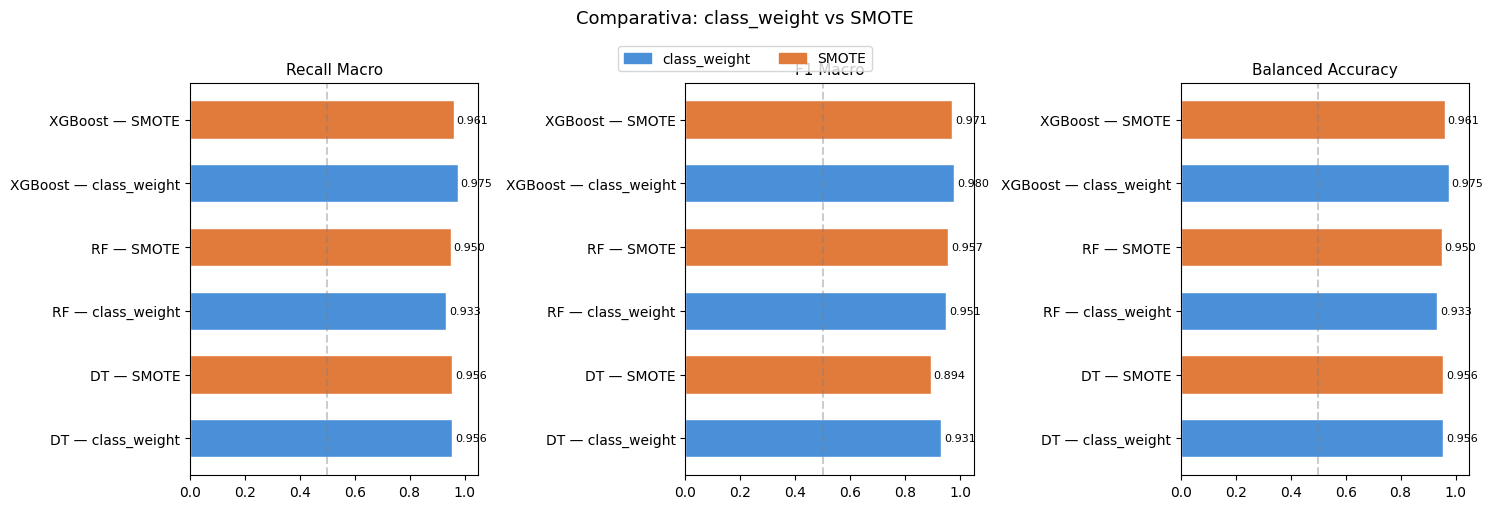

In [ ]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas_plot = ['Recall Macro', 'F1 Macro', 'Balanced Accuracy']

for ax, metrica in zip(axes, metricas_plot):
    colores = ['#4A90D9' if e == 'class_weight' else '#E07B3B'
               for e in comparativa_12['Estrategia']]
    bars = ax.barh(comparativa_12['Modelo'], comparativa_12[metrica],
                   color=colores, edgecolor='white', height=0.6)
    ax.set_xlim(0, 1.05)
    ax.set_title(metrica, fontsize=11)
    ax.axvline(0.5, color='grey', linestyle='--', alpha=0.4)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
                f'{w:.3f}', va='center', fontsize=8)

# Leyenda
leyenda = [Patch(color='#4A90D9', label='class_weight'),
           Patch(color='#E07B3B', label='SMOTE')]
fig.legend(handles=leyenda,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.95),
           ncol=2,
           fontsize=10,
           frameon=True)

plt.suptitle("Comparativa: class_weight vs SMOTE", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

El gráfico compara las 6 configuraciones en tres métricas (Recall Macro, F1 Macro, Balanced Accuracy) usando colores para distinguir la estrategia (azul = class_weight, naranja = SMOTE).

Interpretación esperada del gráfico:
* Para Árbol de Decisión: SMOTE debería mejorar moderadamente el Recall (detecta más ataques minoritarios) pero puede bajar algo la Precision (más falsas alarmas).
* Para Random Forest: SMOTE podría mejorar el Recall ligeramente, con impacto mínimo en Precision.
* Para XGBoost: el efecto de SMOTE probablemente sea mínimo o incluso ligeramente negativo, porque XGBoost + class_weight ya era excelente. Añadir muestras sintéticas puede introducir más ruido que señal cuando el modelo de partida ya es muy bueno.

### 3.5.5 Selección del Modelo Final y Evaluación en el Test Set

In [ ]:
# Diccionario con todos los resultados de CV (1ra y 2da Iteración)
resultados_finales = {
    'DT — class_weight': (cv_dt_base, dt_base, False),
    'DT — SMOTE': (cv_dt_smote, dt_smote, True),
    'RF — class_weight': (cv_rf_base, rf_base, False),
    'RF — SMOTE': (cv_rf_smote, rf_smote, True),
    'XGBoost — class_weight': (cv_xgb_base, xgb_base, False),
    'XGBoost — SMOTE': (cv_xgb_smote, xgb_smote_base, True),
}

# Elegimos el modelo con mayor F1 Macro promedio en CV
mejor_nombre_final = max(
    resultados_finales.keys(),
    key=lambda k: resultados_finales[k][0]['test_f1_macro'].mean()
)
cv_ganador, modelo_ganador, usa_smote = resultados_finales[mejor_nombre_final]

print(f"Modelo ganador (por F1 Macro en CV): {mejor_nombre_final}")
print(f" F1 Macro (CV): {cv_ganador['test_f1_macro'].mean():.4f} (± {cv_ganador['test_f1_macro'].std():.4f})")
print(f" Recall Macro (CV): {cv_ganador['test_recall_macro'].mean():.4f}")
print(f" Precision Macro (CV): {cv_ganador['test_precision_macro'].mean():.4f}")
print(f" Balanced Accuracy (CV): {cv_ganador['test_balanced_accuracy'].mean():.4f}")


Modelo ganador (por F1 Macro en CV): XGBoost — class_weight
 F1 Macro (CV): 0.9798 (± 0.0098)
 Recall Macro (CV): 0.9752
 Precision Macro (CV): 0.9886
 Balanced Accuracy (CV): 0.9752


## 3.6 Tercera Iteración - Selección de variables

El dataset original tiene 66 features de red. Muchas están altamente correlacionadas (por ejemplo, distintas estadísticas del mismo flujo: media, máximo, mínimo de packet length). Reducir la dimensionalidad tiene tres beneficios concretos:

- **Modelos más livianos**: menos features, menos memoria y tiempo de entrenamiento.
- **Menor riesgo de overfitting**: eliminar variables irrelevantes o redundantes mejora la generalización.
- **Mayor interpretabilidad**: es más fácil explicar un modelo con 15 variables que con 70.

Comparamos dos métodos de selección:

| Método | Criterio | Depende del modelo? |
|---|---|---|
| **Importancia XGBoost** | Reducción de error en cada split (gain) |  Sí |
| **SelectKBest ANOVA-F** | Separación estadística entre clases |  No |"""))


### 3.6.1 Importancia de Variables — XGBoost

XGBoost calcula internamente cuánto contribuye cada variable a reducir el error del modelo. Usamos `importance_type='gain'` (ganancia promedio en reducción de error por split), que es más informativo que la frecuencia de uso (`weight`) porque mide impacto real, no popularidad.

In [ ]:
# Entrenamos XGBoost con todas las features (configuración ganadora de la Iteración 2)
xgb_completo = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_completo.fit(X_train, y_train, sample_weight=pesos_train)

# Extraer importancias por GAIN
importancias_gain = xgb_completo.get_booster().get_score(importance_type='gain')

# Convertir a Series y ordenar
importancias_serie = pd.Series(importancias_gain).sort_values(ascending=False)

print(f"Features con importancia > 0 : {len(importancias_serie)}")
print(f"Features con importancia = 0 : {X_train.shape[1] - len(importancias_serie)}")
print(f"\nTop 10 features (gain):")
print(importancias_serie.head(10).round(2))

Features con importancia > 0 : 60
Features con importancia = 0 : 5

Top 10 features (gain):
Avg Bwd Segment Size       1400.73
PSH Flag Count              517.92
Fwd Packet Length Min       516.05
Fwd Packet Length Std       433.01
Bwd Packet Length Min       249.61
Fwd Packet Length Max       211.52
Bwd Packets/s               175.49
Bwd Packet Length Mean      167.97
Bwd Packet Length Std       166.29
Init_Win_bytes_backward     165.25
dtype: float64


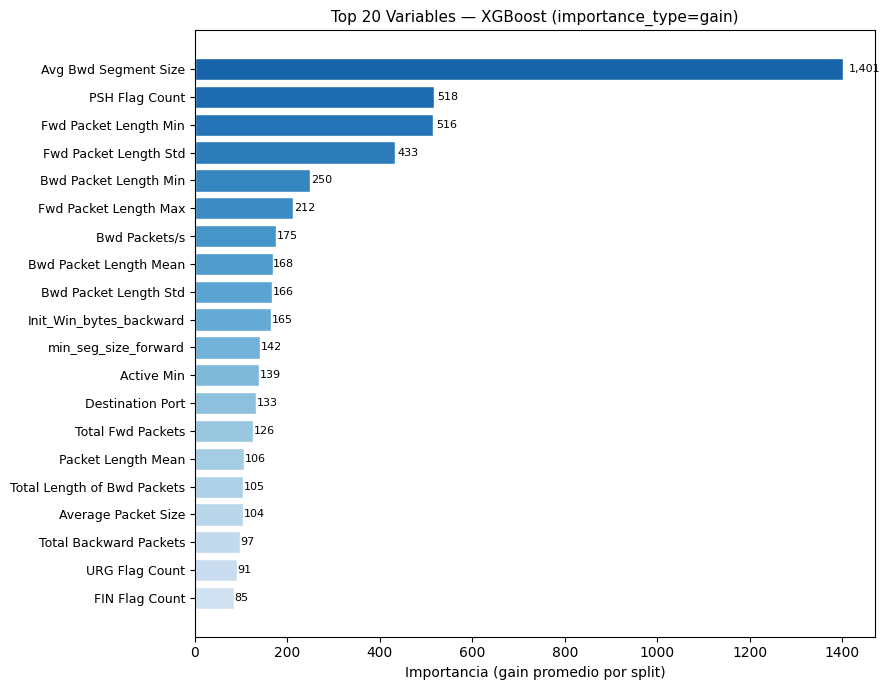

In [ ]:
# Gráfico: Top 20 features por importancia (gain)
top20 = importancias_serie.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colores = plt.cm.Blues_r(np.linspace(0.2, 0.8, len(top20)))
ax.barh(top20.index[::-1], top20.values[::-1], color=colores[::-1], edgecolor='white')

ax.set_xlabel('Importancia (gain promedio por split)', fontsize=10)
ax.set_title('Top 20 Variables — XGBoost (importance_type=gain)', fontsize=11)
ax.tick_params(axis='y', labelsize=9)

for i, (idx, val) in enumerate(zip(top20.index[::-1], top20.values[::-1])):
    ax.text(val * 1.01, i, f'{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Selección de las top K features por importancia XGBoost
K = 20
top_k_features = importancias_serie.head(K).index.tolist()

X_train_xgb = X_train[top_k_features]
X_test_xgb  = X_test[top_k_features]

print(f"Features originales: {X_train.shape[1]}")
print(f"Features seleccionadas (K={K}): {len(top_k_features)}")
print(f"\\nFeatures seleccionadas:")
for i, feat in enumerate(top_k_features, 1):
    print(f"  {i:2d}. {feat}")

# Validación cruzada de XGBoost con top-K features (bucle manual por sample_weight)
xgb_topk = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

X_train_arr = np.asarray(X_train_xgb)
y_train_arr = np.asarray(y_train)

metricas_topk = {k: [] for k in ['recall_macro', 'precision_macro', 'f1_macro', 'balanced_accuracy', 'fit_time']}

for idx_tr, idx_val in CV.split(X_train_arr, y_train_arr):
    modelo_fold = clone(xgb_topk)
    X_tr, X_val = X_train_arr[idx_tr], X_train_arr[idx_val]
    y_tr, y_val = y_train_arr[idx_tr], y_train_arr[idx_val]
    pesos_fold  = compute_sample_weight(class_weight='balanced', y=y_tr)

    t0 = time.time()
    modelo_fold.fit(X_tr, y_tr, sample_weight=pesos_fold)
    metricas_topk['fit_time'].append(time.time() - t0)

    pred = modelo_fold.predict(X_val)
    metricas_topk['recall_macro'].append(recall_score(y_val, pred, average='macro'))
    metricas_topk['precision_macro'].append(precision_score(y_val, pred, average='macro'))
    metricas_topk['f1_macro'].append(f1_score(y_val, pred, average='macro'))
    metricas_topk['balanced_accuracy'].append(balanced_accuracy_score(y_val, pred))

cv_xgb_topk = {f'test_{k}' if k != 'fit_time' else k: np.array(v)
               for k, v in metricas_topk.items()}

mostrar_cv_resultados(cv_xgb_topk, f'XGBoost — Top {K} features (importancia gain)')


Features originales: 65
Features seleccionadas (K=20): 20
\nFeatures seleccionadas:
   1. Avg Bwd Segment Size
   2. PSH Flag Count
   3. Fwd Packet Length Min
   4. Fwd Packet Length Std
   5. Bwd Packet Length Min
   6. Fwd Packet Length Max
   7. Bwd Packets/s
   8. Bwd Packet Length Mean
   9. Bwd Packet Length Std
  10. Init_Win_bytes_backward
  11. min_seg_size_forward
  12. Active Min
  13. Destination Port
  14. Total Fwd Packets
  15. Packet Length Mean
  16. Total Length of Bwd Packets
  17. Average Packet Size
  18. Total Backward Packets
  19. URG Flag Count
  20. FIN Flag Count
 XGBoost — Top 20 features (importancia gain)
  Recall Macro: 0.9579  (± 0.0118)
  Precision Macro: 0.9510  (± 0.0109)
  F1 Macro: 0.9541  (± 0.0112)
  Balanced Accuracy: 0.9579  (± 0.0118)
Tiempo promedio/fold: 46.4s


### 3.6.2 SelectKBest con ANOVA-F

ANOVA-F (Analysis of Variance F-test) mide cuánto varía el promedio de cada feature entre las distintas clases respecto a la variación dentro de cada clase. Una feature con F-score alto separa bien las clases.

**Ventaja**: es independiente del modelo. No necesita entrenar XGBoost primero.

**Limitación**: solo captura relaciones lineales entre cada feature y el target. No detecta interacciones entre variables (algo que XGBoost sí aprende mediante los splits).


In [ ]:
# Aplicar SelectKBest con ANOVA-F sobre X_train
K_anova = 20
selector = SelectKBest(score_func=f_classif, k=K_anova)
selector.fit(X_train, y_train)

# F-scores ordenados
f_scores = pd.Series(selector.scores_, index=X_train.columns).sort_values(ascending=False)

features_anova = f_scores.head(K_anova).index.tolist()
X_train_anova  = X_train[features_anova]
X_test_anova   = X_test[features_anova]

print(f"Top {K_anova} features por ANOVA-F:")
for i, feat in enumerate(features_anova, 1):
    print(f"  {i:2d}. {feat}  (F={f_scores[feat]:,.0f})")

Top 20 features por ANOVA-F:
   1. Bwd Packet Length Mean  (F=21,013)
   2. Avg Bwd Segment Size  (F=21,013)
   3. PSH Flag Count  (F=19,386)
   4. Bwd Packet Length Max  (F=18,656)
   5. Packet Length Mean  (F=18,514)
   6. Packet Length Std  (F=18,394)
   7. Average Packet Size  (F=18,189)
   8. Bwd Packet Length Std  (F=17,920)
   9. Max Packet Length  (F=17,535)
  10. Idle Max  (F=11,175)
  11. Flow IAT Max  (F=11,174)
  12. Fwd IAT Std  (F=11,166)
  13. Packet Length Variance  (F=11,165)
  14. Fwd IAT Max  (F=11,077)
  15. Idle Mean  (F=10,696)
  16. Flow IAT Std  (F=9,964)
  17. Idle Min  (F=9,758)
  18. ACK Flag Count  (F=8,761)
  19. Flow Duration  (F=7,806)
  20. Fwd IAT Total  (F=7,788)


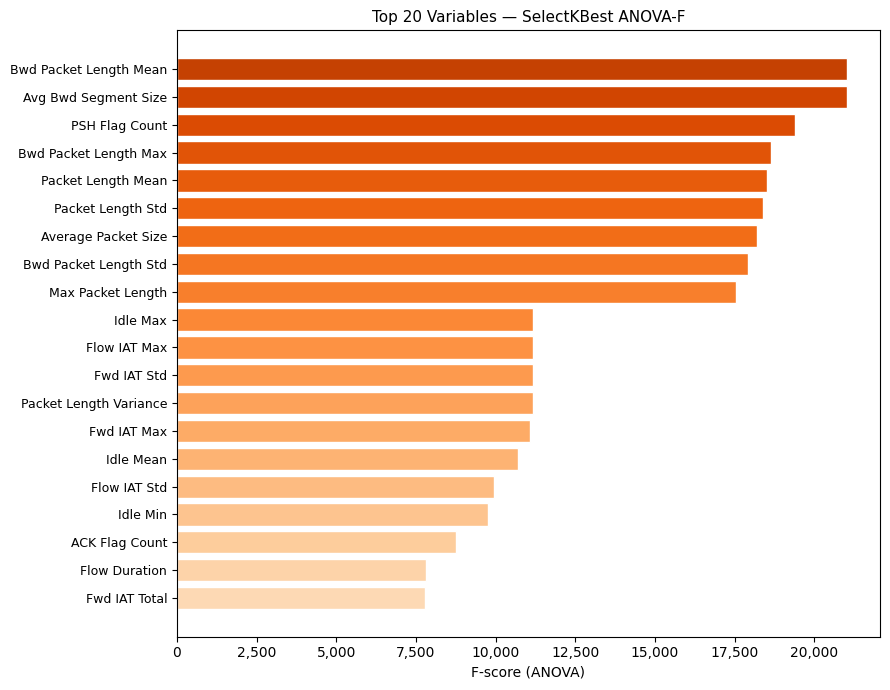

In [ ]:
import matplotlib.ticker as mticker

# Gráfico: Top 20 features por F-score ANOVA
top20_anova = f_scores.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colores2 = plt.cm.Oranges_r(np.linspace(0.2, 0.8, len(top20_anova)))
ax.barh(top20_anova.index[::-1], top20_anova.values[::-1],
        color=colores2[::-1], edgecolor='white')

ax.set_xlabel('F-score (ANOVA)', fontsize=10)
ax.set_title('Top 20 Variables — SelectKBest ANOVA-F', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
# Validación cruzada de XGBoost con features ANOVA-F (bucle manual)
xgb_anova_modelo = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

X_tr_anova_arr = np.asarray(X_train_anova)

metricas_anova = {k: [] for k in ['recall_macro', 'precision_macro', 'f1_macro', 'balanced_accuracy', 'fit_time']}

for idx_tr, idx_val in CV.split(X_tr_anova_arr, y_train_arr):
    modelo_fold = clone(xgb_anova_modelo)
    X_tr, X_val = X_tr_anova_arr[idx_tr], X_tr_anova_arr[idx_val]
    y_tr, y_val = y_train_arr[idx_tr], y_train_arr[idx_val]
    pesos_fold  = compute_sample_weight(class_weight='balanced', y=y_tr)

    t0 = time.time()
    modelo_fold.fit(X_tr, y_tr, sample_weight=pesos_fold)
    metricas_anova['fit_time'].append(time.time() - t0)

    pred = modelo_fold.predict(X_val)
    metricas_anova['recall_macro'].append(recall_score(y_val, pred, average='macro'))
    metricas_anova['precision_macro'].append(precision_score(y_val, pred, average='macro'))
    metricas_anova['f1_macro'].append(f1_score(y_val, pred, average='macro'))
    metricas_anova['balanced_accuracy'].append(balanced_accuracy_score(y_val, pred))

cv_xgb_anova = {f'test_{k}' if k != 'fit_time' else k: np.array(v)
                for k, v in metricas_anova.items()}

mostrar_cv_resultados(cv_xgb_anova, f'XGBoost — Top {K_anova} features (ANOVA-F)')

 XGBoost — Top 20 features (ANOVA-F)
  Recall Macro: 0.9198  (± 0.0189)
  Precision Macro: 0.7458  (± 0.0050)
  F1 Macro: 0.7914  (± 0.0051)
  Balanced Accuracy: 0.9198  (± 0.0189)
Tiempo promedio/fold: 44.2s


### 3.6.3 Comparativa: Features Completas vs. Selección XGBoost vs. Selección ANOVA-F
Comparamos los tres enfoques usando el mismo modelo (XGBoost con hiperparámetros de la Iteración 2) para aislar el efecto de la selección de variables.

In [ ]:
# CV de XGBoost completo como referencia
X_full_arr = np.asarray(X_train)
metricas_full = {k: [] for k in ['recall_macro', 'precision_macro', 'f1_macro', 'balanced_accuracy', 'fit_time']}

for idx_tr, idx_val in CV.split(X_full_arr, y_train_arr):
    modelo_fold = clone(xgb_completo)
    X_tr, X_val = X_full_arr[idx_tr], X_full_arr[idx_val]
    y_tr, y_val = y_train_arr[idx_tr], y_train_arr[idx_val]
    pesos_fold  = compute_sample_weight(class_weight='balanced', y=y_tr)
    t0 = time.time()
    modelo_fold.fit(X_tr, y_tr, sample_weight=pesos_fold)
    metricas_full['fit_time'].append(time.time() - t0)
    pred = modelo_fold.predict(X_val)
    metricas_full['recall_macro'].append(recall_score(y_val, pred, average='macro'))
    metricas_full['precision_macro'].append(precision_score(y_val, pred, average='macro'))
    metricas_full['f1_macro'].append(f1_score(y_val, pred, average='macro'))
    metricas_full['balanced_accuracy'].append(balanced_accuracy_score(y_val, pred))

cv_xgb_full = {f'test_{k}' if k != 'fit_time' else k: np.array(v)
               for k, v in metricas_full.items()}

mostrar_cv_resultados(cv_xgb_full, f'XGBoost — Todas las features ({X_train.shape[1]} vars)')

 XGBoost — Todas las features (65 vars)
  Recall Macro: 0.9752  (± 0.0198)
  Precision Macro: 0.9886  (± 0.0100)
  F1 Macro: 0.9798  (± 0.0098)
  Balanced Accuracy: 0.9752  (± 0.0198)
Tiempo promedio/fold: 69.2s


In [ ]:
# Tabla comparativa
comparativa_sel = pd.DataFrame({
    'Configuración': [
        f'Completo ({X_train.shape[1]} features)',
        f'Top-{K} XGBoost gain',
        f'Top-{K_anova} ANOVA-F'
    ],
    'Recall Macro': [
        cv_xgb_full['test_recall_macro'].mean(),
        cv_xgb_topk['test_recall_macro'].mean(),
        cv_xgb_anova['test_recall_macro'].mean()
    ],
    'Precision Macro': [
        cv_xgb_full['test_precision_macro'].mean(),
        cv_xgb_topk['test_precision_macro'].mean(),
        cv_xgb_anova['test_precision_macro'].mean()
    ],
    'F1 Macro': [
        cv_xgb_full['test_f1_macro'].mean(),
        cv_xgb_topk['test_f1_macro'].mean(),
        cv_xgb_anova['test_f1_macro'].mean()
    ],
    'Tiempo/fold (s)': [
        cv_xgb_full['fit_time'].mean(),
        cv_xgb_topk['fit_time'].mean(),
        cv_xgb_anova['fit_time'].mean()
    ],
})

print("Comparativa — Selección de Variables")
display(comparativa_sel.set_index('Configuración').round(4))

Comparativa — Selección de Variables


,Recall Macro,Precision Macro,F1 Macro,Tiempo/fold (s)
Configuración,,,,
Completo (65 features),0.9752,0.9886,0.9798,69.2406
Top-20 XGBoost gain,0.9579,0.9510,0.9541,46.4482
Top-20 ANOVA-F,0.9198,0.7458,0.7914,44.2403


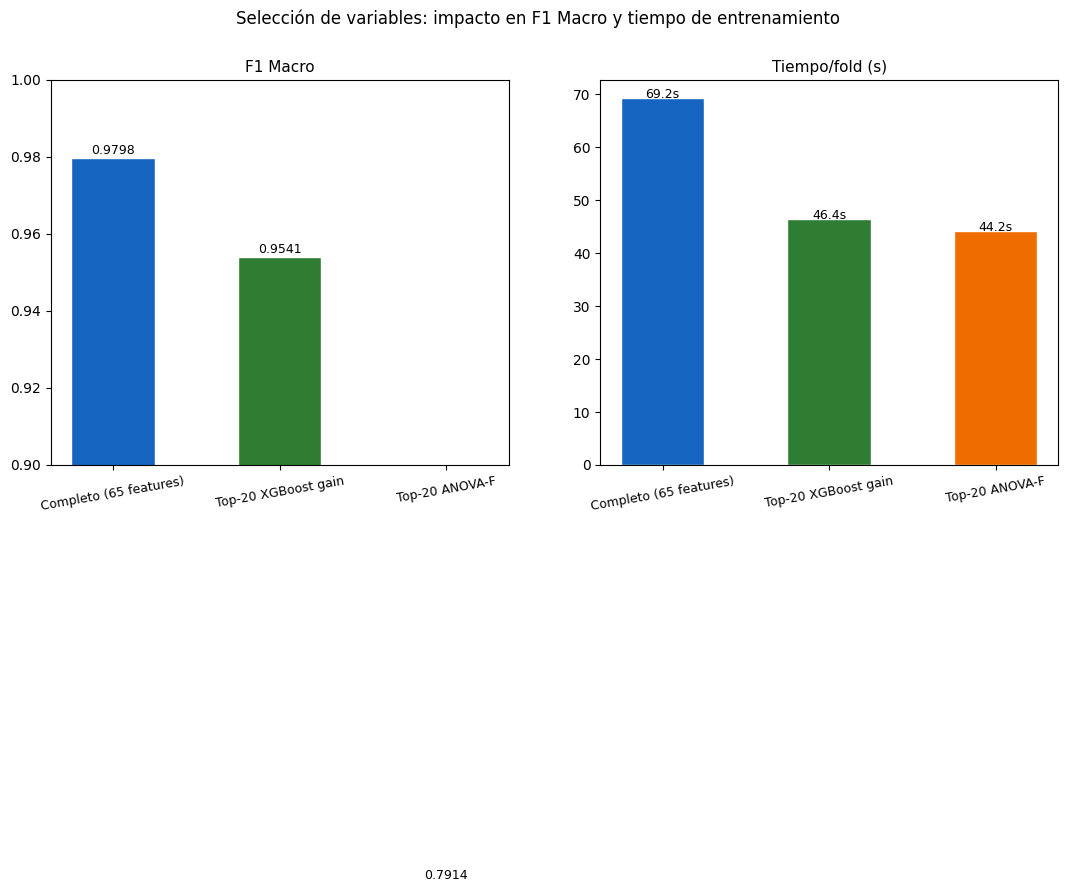

In [ ]:
import matplotlib.ticker as mticker

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

configs   = comparativa_sel['Configuración'].tolist()
colores_s = ['#1565C0', '#2E7D32', '#EF6C00']

for ax, metrica in zip(axes, ['F1 Macro', 'Tiempo/fold (s)']):
    valores = comparativa_sel[metrica].tolist()
    bars = ax.bar(range(len(configs)), valores, color=colores_s, edgecolor='white', width=0.5)
    ax.set_xticks(range(len(configs)))
    ax.set_xticklabels(configs, fontsize=9, rotation=10)
    ax.set_title(metrica, fontsize=11)
    if metrica == 'F1 Macro':
        ax.set_ylim(0.90, 1.00)
    for bar in bars:
        h = bar.get_height()
        label = f'{h:.4f}' if metrica == 'F1 Macro' else f'{h:.1f}s'
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.001,
                label, ha='center', fontsize=9)

plt.suptitle("Selección de variables: impacto en F1 Macro y tiempo de entrenamiento",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# 4. Optimización del modelo

Búsqueda de Hiperparámetros

Los hiperparámetros son configuraciones del modelo que no se aprenden de los datos. Hasta ahora usamos valores razonables por defecto. En esta sección buscamos sistemáticamente la combinación que maximiza el F1 Macro.

**¿Por qué `RandomizedSearchCV` en lugar de `GridSearchCV`?**

`GridSearchCV` evalúa todas las combinaciones posibles. Con 4 hiperparámetros y 4 valores cada uno: $4^4 = 256$ combinaciones × 5 folds = 1.280 entrenamientos. Con XGBoost en Colab, eso tardaría horas.

`RandomizedSearchCV` evalúa una cantidad fija de combinaciones aleatorias (`n_iter=20`), lo que permite explorar el espacio de forma eficiente en una fracción del tiempo.

**Hiperparámetros a optimizar:**

| Hiperparámetro | Descripción | Rango de búsqueda |
|---|---|---|
| `n_estimators` | Cantidad de árboles | 100 – 500 |
| `max_depth` | Profundidad máxima por árbol | 3 – 10 |
| `learning_rate` | Paso de aprendizaje | 0.01 – 0.30 |
| `subsample` | Fracción de filas por árbol | 0.6 – 1.0 |
| `colsample_bytree` | Fracción de features por árbol | 0.6 – 1.0 |
| `min_child_weight` | Mínimo de muestras por hoja | 1 – 10 |

## 4.1 RandomizedSearchCV — XGBoost con features seleccionadas

A diferencia del bucle manual de las iteraciones anteriores, `RandomizedSearchCV` sí permite pasar `sample_weight` a través del parámetro `fit_params`. Los pesos se calculan sobre todo `X_train` y se usan en cada fold del search y en el refit final.

In [ ]:
from scipy.stats import randint, uniform

# Elegimos las features de la selección por importancia XGBoost (sección 7.1)
# Podés cambiarlo a X_train_anova / X_test_anova si ANOVA-F tuvo mejor resultado
X_train_sel = X_train_xgb.copy()
X_test_sel = X_test_xgb.copy()

print(f"Features usadas en la búsqueda : {X_train_sel.shape[1]}")
print(f"Filas de entrenamiento : {X_train_sel.shape[0]:,}")

# Espacio de búsqueda de hiperparámetros
param_dist = {
    'n_estimators': randint(100, 501),
    'max_depth': randint(3, 11),
    'learning_rate': uniform(0.01, 0.29),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 11),
}

# Modelo base para la búsqueda
xgb_search = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(le.classes_),
    random_state=42,
    n_jobs=-1
)

Features usadas en la búsqueda : 20
Filas de entrenamiento : 134,403


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rscv = RandomizedSearchCV(
    estimator=xgb_search,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=CV,
    random_state=42,
    n_jobs=1,
    verbose=1,
    refit=True
)

print("Iniciando búsqueda de hiperparámetros...")
print(f"Combinaciones a evaluar: 20 x 5 folds = 100 entrenamientos")
print("Esto puede tardar varios minutos en Colab.\n")

t0 = time.time()
rscv.fit(
    X_train_sel, y_train,
    sample_weight=pesos_train
)
print(f"\nBúsqueda completada en {(time.time()-t0)/60:.1f} minutos.")

print(f"\nMejores hiperparámetros encontrados:")
for param, valor in rscv.best_params_.items():
    print(f"  {param}: {valor}")
print(f"\nMejor F1 Macro en CV: {rscv.best_score_:.4f}")

Iniciando búsqueda de hiperparámetros...
Combinaciones a evaluar: 20 x 5 folds = 100 entrenamientos
Esto puede tardar varios minutos en Colab.

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Búsqueda completada en 48.7 minutos.

Mejores hiperparámetros encontrados:
  colsample_bytree: 0.7580600944007257
  learning_rate: 0.2787310710802003
  max_depth: 9
  min_child_weight: 8
  n_estimators: 314
  subsample: 0.8083337040103294

Mejor F1 Macro en CV: 0.9582


In [ ]:
# Top 10 combinaciones evaluadas
resultados_busqueda = pd.DataFrame(rscv.cv_results_)
cols_mostrar = [
    'rank_test_score', 'mean_test_score', 'std_test_score',
    'param_n_estimators', 'param_max_depth', 'param_learning_rate',
    'param_subsample', 'param_colsample_bytree', 'param_min_child_weight',
    'mean_fit_time'
]

print("Top 10 combinaciones evaluadas:")
display(
    resultados_busqueda[cols_mostrar]
    .sort_values('rank_test_score')
    .head(10)
    .round(4)
    .reset_index(drop=True)
)

Top 10 combinaciones evaluadas:


,rank_test_score,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,param_colsample_bytree,param_min_child_weight,mean_fit_time
0,1,0.9582,0.0100,314,9,0.2787,0.8083,0.7581,8,27.0973
1,2,0.9570,0.0134,200,3,0.2673,0.9887,0.8550,3,14.7159
2,3,0.9566,0.0139,388,5,0.2150,0.8424,0.9262,3,33.5703
3,4,0.9565,0.0110,466,7,0.2549,0.9315,0.9845,2,41.8188
4,5,0.9556,0.0105,235,10,0.2962,0.6022,0.6298,1,23.6846
5,6,0.9556,0.0135,463,4,0.1874,0.8057,0.7165,3,40.1698
6,7,0.9554,0.0136,392,9,0.0284,0.8918,0.7324,8,35.0749
7,8,0.9551,0.0091,363,6,0.0799,0.6138,0.6924,7,32.9428
8,9,0.9545,0.0108,364,8,0.2832,0.6064,0.6053,2,33.6396
9,10,0.9541,0.0117,300,6,0.1988,0.8493,0.9705,7,25.6430


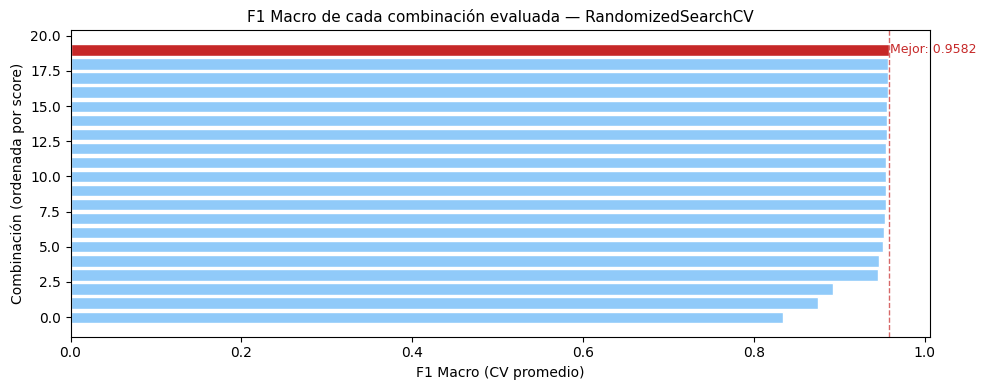

In [ ]:
# Gráfico: F1 Macro de todas las combinaciones evaluadas
fig, ax = plt.subplots(figsize=(10, 4))

scores_ord = resultados_busqueda['mean_test_score'].sort_values().values
colores_b  = ['#C62828' if s == scores_ord.max() else '#90CAF9' for s in scores_ord]

ax.barh(range(len(scores_ord)), scores_ord, color=colores_b, edgecolor='white')
ax.axvline(scores_ord.max(), color='#C62828', linestyle='--', alpha=0.7, linewidth=1)
ax.set_xlabel('F1 Macro (CV promedio)', fontsize=10)
ax.set_ylabel('Combinación (ordenada por score)', fontsize=10)
ax.set_title('F1 Macro de cada combinación evaluada — RandomizedSearchCV', fontsize=11)
ax.text(scores_ord.max() + 0.0005, len(scores_ord) - 1,
        f'Mejor: {scores_ord.max():.4f}',
        va='center', color='#C62828', fontsize=9)
plt.tight_layout()
plt.show()

## 4.2 Evaluación del Modelo Optimizado en el Test Set

El mejor estimador de `RandomizedSearchCV` ya fue re-entrenado automáticamente (`refit=True`) con todos los datos de `X_train_sel`. Lo evaluamos sobre el Test Set para obtener las métricas finales.

In [ ]:
# El mejor modelo ya está entrenado en rscv.best_estimator_
modelo_optimo  = rscv.best_estimator_
y_pred_optimo  = modelo_optimo.predict(X_test_sel)

In [ ]:
# Reporte de clasificación
reporte = classification_report(
    y_test, y_pred_optimo,
    target_names=le.classes_,
    zero_division=0,
    output_dict=True
)
df_reporte = pd.DataFrame(reporte).transpose()
print("REPORTE — XGBoost Optimizado (Test Set)")
display(df_reporte.round(4))

REPORTE — XGBoost Optimizado (Test Set)


,precision,recall,f1-score,support
BENIGN,0.9988,0.9887,0.9937,10000.0000
Botnet,0.9198,0.9974,0.9571,391.0000
Brute Force,1.0000,1.0000,1.0000,2765.0000
DoS-DDoS,0.9938,0.9993,0.9966,10000.0000
PortScan,0.9996,0.9994,0.9995,10000.0000
Rare Attack,0.6429,0.6923,0.6667,13.0000
Web Attack,0.9462,0.9769,0.9613,432.0000
accuracy,0.9958,0.9958,0.9958,0.9958
macro avg,0.9287,0.9506,0.9393,33601.0000
weighted avg,0.9959,0.9958,0.9958,33601.0000


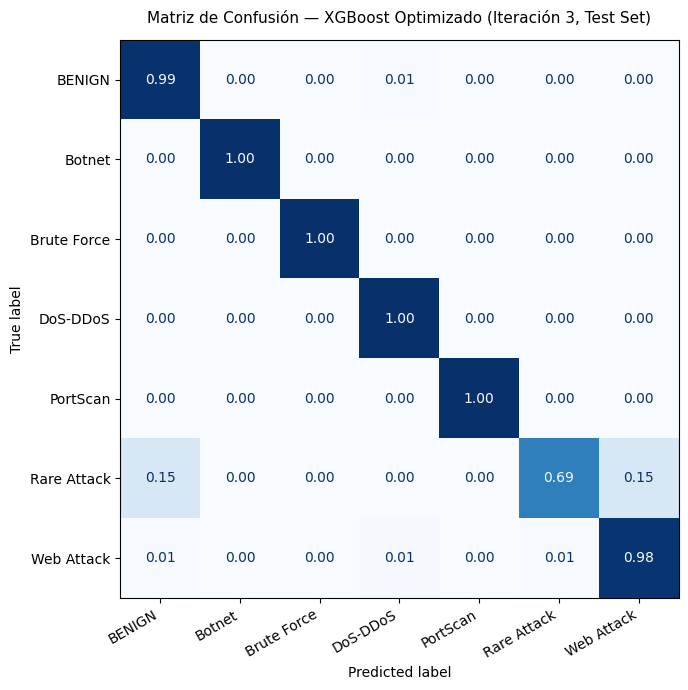

In [ ]:
# Matriz de confusión del modelo optimizado
graficar_confusion(
    y_test, y_pred_optimo,
    'Matriz de Confusión — XGBoost Optimizado (Iteración 3, Test Set)',
    le
)

## 4.3 Comparativa final: Iteraciones 2 vs. 3
Comparamos el modelo de la Iteración 2 (XGBoost, todas las features, hiperparámetros por defecto) contra el modelo optimizado de esta iteración (features seleccionadas + hiperparámetros optimizados).


In [ ]:
# Métricas del modelo optimizado sobre Test Set
f1_opt = f1_score(y_test, y_pred_optimo, average='macro')
rec_opt = recall_score(y_test, y_pred_optimo, average='macro')
prec_opt = precision_score(y_test, y_pred_optimo, average='macro')
bacc_opt = balanced_accuracy_score(y_test, y_pred_optimo)

print("=" * 58)
print("COMPARATIVA FINAL — Test Set")
print("=" * 58)
print(f"{'Métrica':<25} {'It.2 (base)':>14} {'It.3 (opt)':>14}")
print("-" * 58)
print(f"{'F1 Macro':<25} {'(ver It.2)':>14} {f1_opt:>14.4f}")
print(f"{'Recall Macro':<25} {'(ver It.2)':>14} {rec_opt:>14.4f}")
print(f"{'Precision Macro':<25} {'(ver It.2)':>14} {prec_opt:>14.4f}")
print(f"{'Balanced Accuracy':<25} {'(ver It.2)':>14} {bacc_opt:>14.4f}")
print(f"{'Nro. de features':<25} {X_train.shape[1]:>14} {X_train_sel.shape[1]:>14}")
print("=" * 58)
print("\\nMejores hiperparámetros (Iteración 3):")
for p, v in rscv.best_params_.items():
    print(f"  {p}: {v}")

COMPARATIVA FINAL — Test Set
Métrica                      It.2 (base)     It.3 (opt)
----------------------------------------------------------
F1 Macro                      (ver It.2)         0.9393
Recall Macro                  (ver It.2)         0.9506
Precision Macro               (ver It.2)         0.9287
Balanced Accuracy             (ver It.2)         0.9506
Nro. de features                      65             20
\nMejores hiperparámetros (Iteración 3):
  colsample_bytree: 0.7580600944007257
  learning_rate: 0.2787310710802003
  max_depth: 9
  min_child_weight: 8
  n_estimators: 314
  subsample: 0.8083337040103294


# 5. Conclusiones